In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/ast/git/nuru/env/bin/python


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import collections, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import pandas
import scipy.io.wavfile
import scipy.signal
from scipy import stats

import pyaudio
# import aubio
# import bob.ap

In [4]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

from smanmi import abase, audio, colors as C, effects as E, hotplug, logic as L, palette as P, signals as S, util
from nuru import animations as A, features, settings, state

Signal = L.Signal
Effect = E.Effect

# hp = hotplug.HotPlug()

In [5]:
class Test(L.Signal):
    
    def init(self, x):
        ...
        
    def call(self, y):
        print('x', self.x, 'y', y)
        return 33
        
t = Test(x=L.Named('closeness') | S.To(0, 5))

signals = dict(y=3, z=4, closeness=2)

t(**signals)

x 10 y 3


33

In [6]:
A.xyz_mapping[:, 0].min(), A.xyz_mapping[:, 0].max()

(-1.41762375831604, 1.0628626346588135)

# Palettes

In [247]:
def plot_palette(p, w=200, h=10, ax=None, title=None, title_col='#aaa'):
    cp = P.Palette(colors=p)
    if ax is None:
        plt.figure()
        ax = plt.gca()
    row = np.array([cp(value=v) for v in np.linspace(0, 1, w)])
    ax.imshow(np.array([
        row for y in range(h)
    ]))
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title, color=title_col)

array([0.97074142, 0.59359681, 0.09681373])

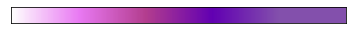

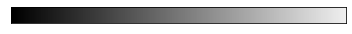

In [248]:
# easy to define new palettes

# https://coolors.co/ffffff-ea7af4-b43e8f-6200b3-8451ad
plot_palette(P.parse_colors_co_scss('''
$color1: rgba(255, 255, 255, 1);
$color2: rgba(234, 122, 244, 1);
$color3: rgba(180, 62, 143, 1);
$color4: rgba(98, 0, 179, 1);
$color5: rgba(132, 81, 173, 1);
'''))

plot_palette(P.parse_colors_hex([(0, '000'), (1, 'fff')]))

# this is how they work
P.Palette(P.funny_rainbow)(value=0.1)

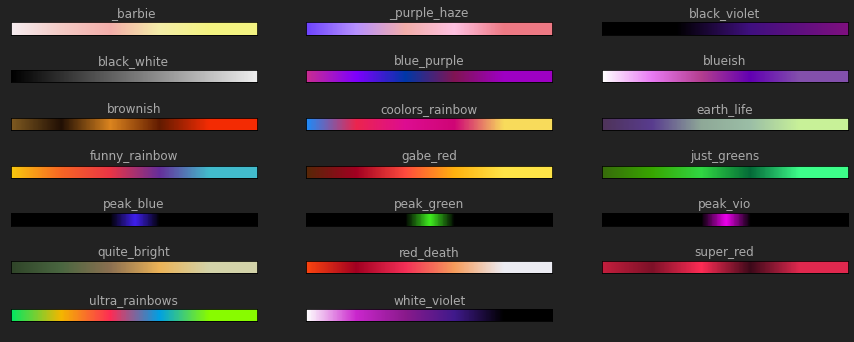

In [249]:
# currently predefined palettes

def ispalette(p):
    return isinstance(p, list) and len(p) > 1 and isinstance(p[0], P.ColorPoint)

palettes = {
    name: getattr(P, name)
    for name in dir(P)
    if ispalette(getattr(P, name))
}

cols = 3
rows = len(palettes) // cols + 1
_, axs = plt.subplots(rows, cols, figsize=(15, 6), facecolor='#222')
for i, name in enumerate(sorted(palettes)):
    ax = axs[i // cols][i % cols]
    plot_palette(palettes[name], ax=ax, title=name)
for i in range(len(palettes), cols * rows):
    axs[i // cols][i % cols].axis('off')

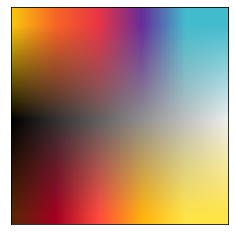

In [250]:
ip = P.InterpolPalette(L.Named('ipv'), [
    (-1, P.gabe_red),
    (0, P.black_white),
    (1, P.funny_rainbow),
])

# O(n^2) !!
def plot_interpol_palette(ip, ipv_name, vmin, vmax, w=200, h=200, ax=None, title=None):
    if ax is None:
        plt.figure()
        ax = plt.gca()
    ax.imshow(np.array([
        [ip(value=value, **{ipv_name: valence}) for value in np.linspace(0, 1, w)]
        # vmin bottom
        for valence in np.linspace(vmax, vmin, h)
    ]))
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title)

plot_interpol_palette(ip, 'ipv', -1.1, 1.2)

In [260]:
p = P.Palette(palettes['ultra_rainbows'])
p(value=0)

array([0.015625  , 0.90234375, 0.3828125 ])

In [262]:
S.Const(1) | S.Int(mod=1)

Init signature: S.Int(*args, **params)
Docstring:      Integrates the signal.
File:           ~/git/nuru/py/smanmi/signals.py
Type:           type
Subclasses:     


# Compose

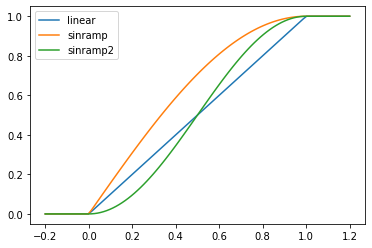

In [22]:
xs = np.linspace(-0.2, 1.2, 100)
plt.plot(xs, S.linear(xs), label='linear')
plt.plot(xs, S.sinramp(xs), label='sinramp')
plt.plot(xs, S.sinramp2(xs), label='sinramp2')
plt.legend()

# r-phi : Display[S]

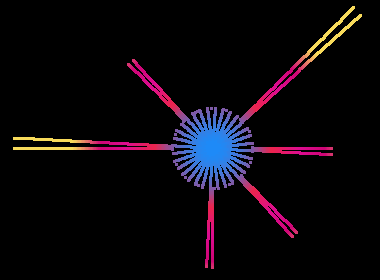

In [121]:
# slightly modified from ./mapping2.ipynb

from PIL import Image, ImageDraw

class Display:

    def __init__(self, width=800, height=600, d=2, scale=77):
        self.width = width
        self.height = height
        self.scale = scale
        self.d = d

    def circle(self, draw, phi, r, col, d):
        x = self.width * .56 + np.sin(phi) * self.scale * r
        y = self.height *  .53 - np.cos(phi) * self.scale * r
        draw.ellipse((x-d/2, y-d/2, x+d/2, y+d/2), fill=tuple(col))

    def draw(self, rgb):
        """Colors in `rgb` range from 0..1 for every pixel."""
        im = Image.new('RGB', (self.width, self.height), 'black')
        draw = ImageDraw.Draw(im)

        rgb = (255 * rgb).astype('uint8')
        for (phi, r), col in zip(A.phi_r_mapping, rgb):
            self.circle(draw, phi, r, col, self.d)
        return im

class DisplayS(Display):
    def __init__(self):
        super().__init__(width=380, height=280, d=2, scale=40)

anim = A.R() | S.Lin(0, 1/5) | S.Tocos() | P.Palette(P.coolors_rainbow)
DisplayS().draw(anim())

## stripes

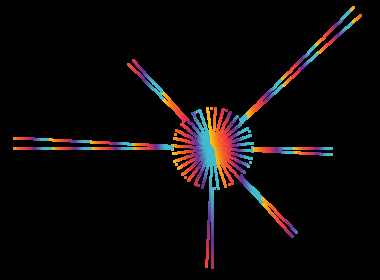

In [92]:
anim = A.PhiRXY(dg=10) | S.T() | S.ElementAt(0) | S.Mod(1) | C.Palette(P.funny_rainbow)
DisplayS().draw(anim())

## gaussian

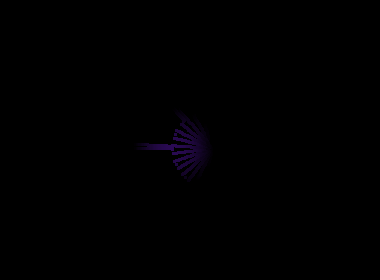

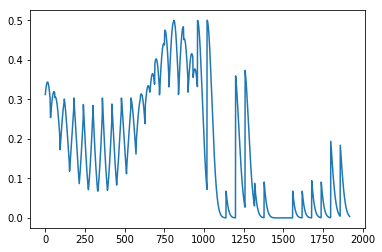

In [172]:
anim = A.GaussianDroplet(
    sigma=1,
    phi=3 * np.pi / 2,
    r=1,
) | S.Norm() | S.Lin(0, .5)
# anim = A.add([anim, anim])
plt.plot(anim())
anim |= C.Palette(P.black_violet)
DisplayS().draw(anim())

## heart

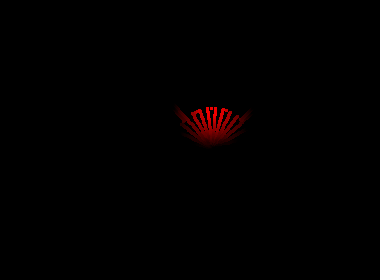

In [225]:
p = P.parse_colors_hex([
    (0, '000'),
    (0.8, 'f00'),
    (1, 'f00'),
])

anim = A.Dist2D(phi=0, r=1) | S.Lin(1, -1) | S.Lin(0, L.Named('heart')) | C.Palette(p)

DisplayS().draw(anim(heart=1))

## spiral

In [67]:
phi_r_mapping = A.phi_r_mapping

In [ ]:


spiral_palette = P.parse_colors_hex([
    (0, '000'),
    (0.3, 'f0f'),
    (0.4, 'f0f'),
    (0.6, 'f0f'),
    (0.7, 'f0f'),
    (1, '000'),
])


def spiral():
    return A.Spiral(0.1, 1) | S.Mod(1) | C.Palette(spiral_palette)



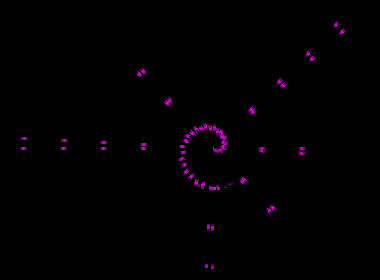

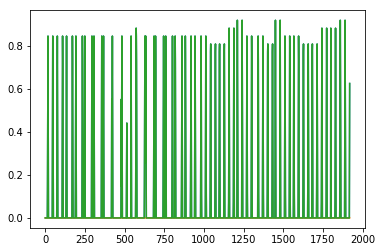

In [106]:
class Spiral(L.Signal):
    
    def init(self, dphi=1, dr=1.5):
        pass
    
    def call(self, t):
        return t + (
            phi_r_mapping[:, 0] * self.dphi
            + phi_r_mapping[:, 1] * self.dr
        )
    
anim = Spiral() | S.Mod(1) | C.Palette(P.coolors_rainbow)


spiral_palette = P.parse_colors_hex([
    (0, '000'),
    (0.4, '000'),
    (0.5, 'f0f'),
    (0.6, '000'),
    (1, '000'),
])


def spiral():
    return A.Spiral(.5/np.pi, 1) | S.Mod(1) | C.Palette(spiral_palette)


vs = spiral()(t=0)
plt.plot(vs);
DisplayS().draw(vs)


## compress waves

10.585000083063374
10.585000083063374


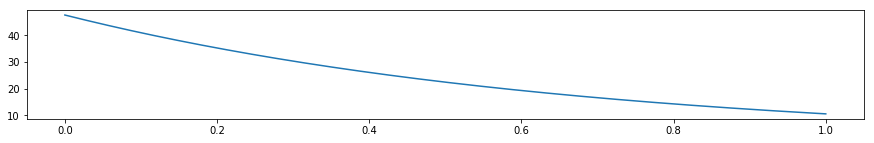

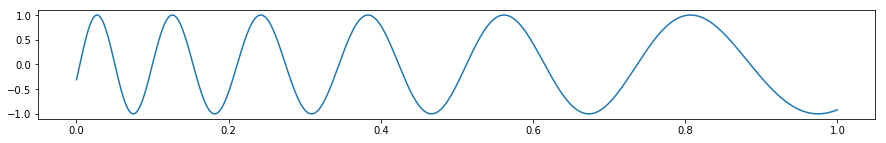

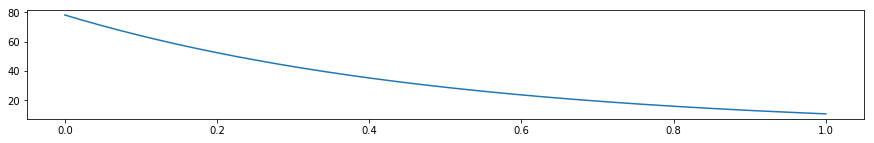

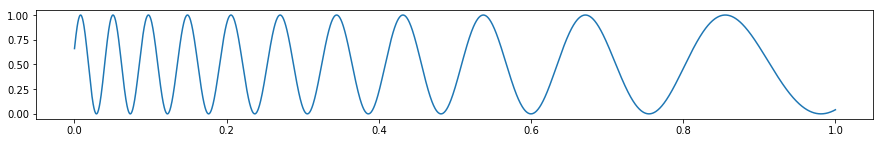

In [233]:
x = np.linspace(0, 1, 2000)
figsize = (15, 2)

u_ = u = 5 * np.exp((1.5 - x) * 1.5)
print(u[-1])
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, np.sin(u))
u = 0.01 * np.exp((1.5 - x) * 2)
u *= u_[-1] / u[-1]
print(u[-1])
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, 0.5 + 0.5 * np.sin(u))

None

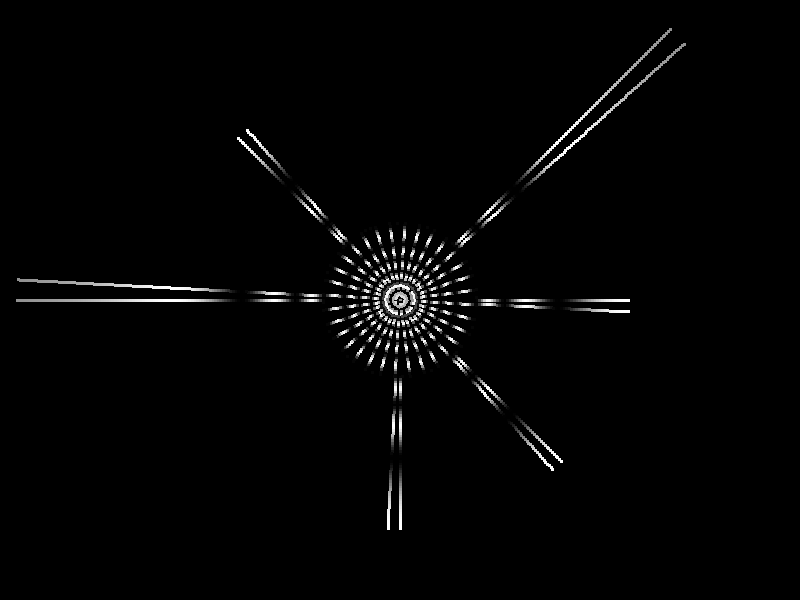

In [258]:
r = A.phi_r_mapping[:, 1]
x = r / r.max()

u = 5 * np.exp((1.5 - x) * 1.5)
u = 10 * np.exp((1.5 - x) * 1.5)
u = 5 * np.exp((1.5 - x) * 2)
u = 2 * np.exp((1.5 - x) * 3)
u = 0.2 * np.exp((1.5 - x) * 4)
u = 0.03 * np.exp((1.5 - x) * 5)
u = 0.007 * np.exp((1.5 - x) * 6)

v = 0.5 + 0.5 * np.sin(u)
Display().draw(np.vstack([v, v, v]).T)

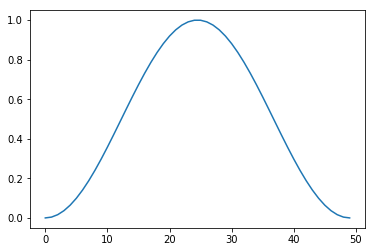

In [257]:
tocos = lambda x: 1 - (0.5 + 0.5 * np.cos(2 * x * np.pi))
plt.plot(tocos(np.linspace(0, 1)))

In [255]:
r = A.phi_r_mapping[:, 1]
x = r / r.max()

def cosipol(start=0, stop=1, steps=25):
    for phi in np.linspace(0, np.pi, steps):
        y = 1 - (0.5 + 0.5 * np.cos(phi))
        yield start + (stop - start) * y

ims = []
ue = (5 * np.exp((1.5 - x) * 1.5))[x.argmax()]
# for f in cosipol(.004, .006, 25):
#     u = f * np.exp((1.5 - x) * 6)
def forexp(exp):
    u = np.exp((1.5 - x) * exp)
    u *= ue / u[x.argmax()]
    return 0.5 + 0.5 * np.sin(u)
for exp in cosipol(1.5, 1.8, 25):
    vr = vg = vb = forexp(exp)
    vg = forexp(exp * 1.01) * 0
    vb = forexp(exp * 1.03)
    im = Display().draw(np.vstack([vr, vg, vb]).T)
    ims.append(im)
ims[0].save('generated.gif', append_images=ims[1:] + ims[::-1], save_all=True, duration=20, loop=0)
from IPython import display


In [217]:
!ls -lh *.gif

-rw-r--r--  1 andreassteiner  staff   2.1M Apr 26 22:47 test.gif


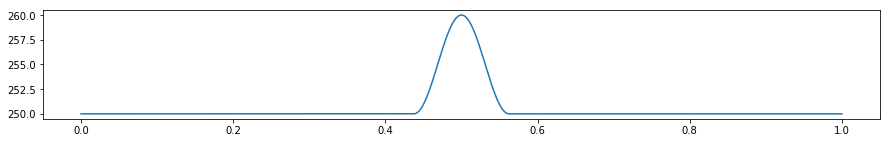

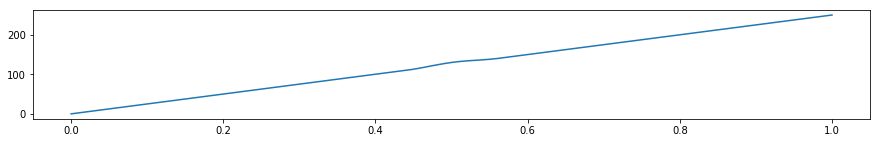

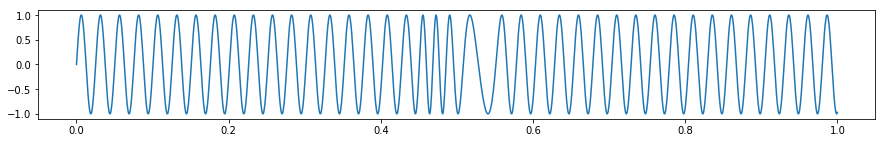

In [129]:
x = np.linspace(0, 1, 2000)
figsize = (15, 2)

f = 8
dx = 0.5
x_ = f * (x - dx)
pulse = np.piecewise(
    x_,
    [x_ < -0.5, x_ > -0.5, x_ > 0.5],
    [0, lambda x: 0.5 * (1 + np.cos(x * 2 * np.pi)), 0],
)
u = 250 + 10 * pulse
# u = 200 + 20 * pulse  # ugly b/c diff(u * x) is not >0 everywhere
plt.figure(figsize=figsize)
plt.plot(x, u)
plt.figure(figsize=figsize)
plt.plot(x, u * x)
plt.figure(figsize=figsize)
plt.plot(x, np.sin(x * u));

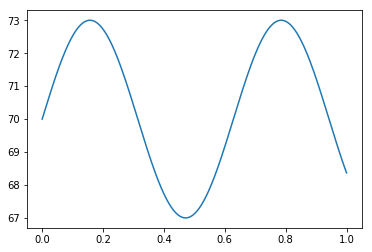

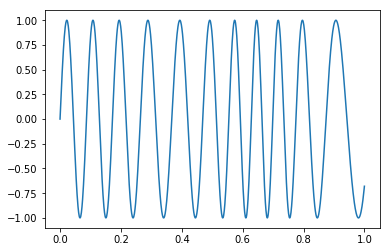

In [69]:
x = np.linspace(0, 1, 1000)

w = 70 + 3 * np.sin(10*x)
plt.plot(x, w)
plt.figure()
plt.plot(x, np.sin(x * w));

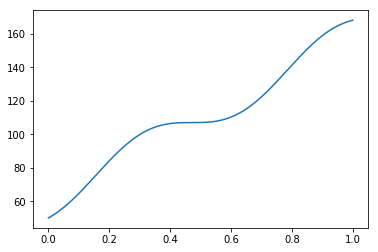

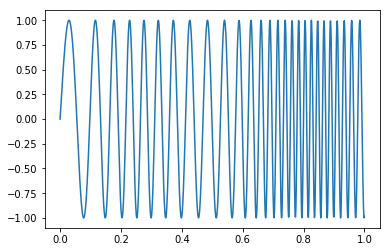

In [55]:
x = np.linspace(0, 1, 1000)

w = (1 + np.sin(10 * x)) / 10
w[0] = 50
w = w.cumsum()
plt.plot(x, w)
plt.figure()
plt.plot(x, np.sin(x * w));

## activations

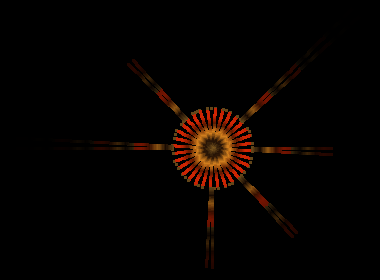

In [26]:
env = A.R() | S.Norm() | S.F(S.gauss_std, 0.3)
anim = A.R() | S.Mod(1) | P.Palette(P.brownish)

anim *= env

# plt.plot(env())
DisplayS().draw(anim())

# Projections

In [117]:
!ls -lh *.png

-rw-r--r--@ 1 ast  staff   360K  4 Oct 18:11 autumn_forest.png
-rw-r--r--  1 ast  staff   302K 23 Sep 21:47 mapping_2D.png
-rw-r--r--  1 ast  staff   252K 23 Sep 21:47 mapping_3D.png


(354, 530, 3)


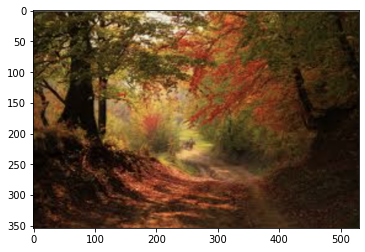

In [420]:
import PIL
img = PIL.Image.open('../images/autumn_forest.png')
arr = np.array(img)[..., :3]
print(arr.shape)
image = arr[..., :3] / 256.
plt.imshow(image);

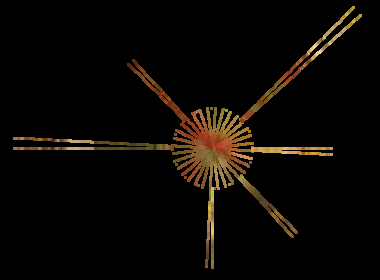

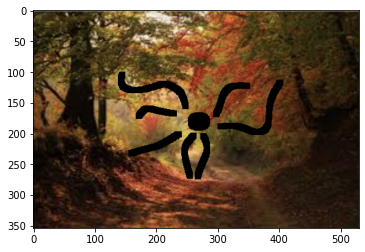

In [423]:
proj = A.Proj(image, .5, 0)
plt.imshow(proj.debug())
DisplayS().draw(proj())

In [415]:
xy = proj.xy()

In [417]:
# 44% doubles
len(set(map(tuple, xy.astype(int)))) / len(xy)

0.4390625

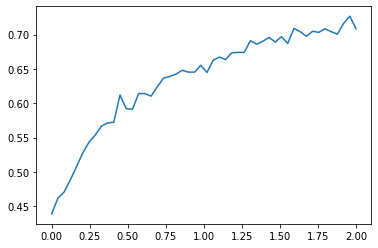

In [418]:
# jitter to have fewer identical coordinates after rounding
sigmas = np.linspace(0, 2, 50)
def unique(xy):
    return len(set(map(tuple, xy.astype(int))))
plt.plot(sigmas, [
    unique(xy + np.random.normal(0, sigma, xy.shape)) / len(xy)
    for sigma in sigmas
]);

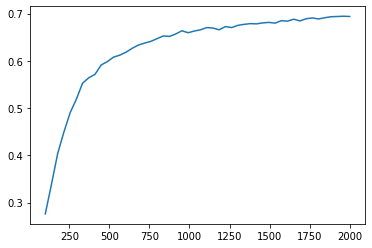

In [419]:
# increasing resolution is less effetive
xy_ = xy @ np.array([
    [1/xy[:, 0].max(), 0],
    [0, -1/xy[:, 1].min()],
])
resolutions = np.linspace(100, 2000, 50)
plt.plot(resolutions, [
    unique(xy_ * resolution) / len(xy)
    for resolution in resolutions
]);

In [ ]:
# TODO : magnify center / non-linear transforms

# Rotating shape

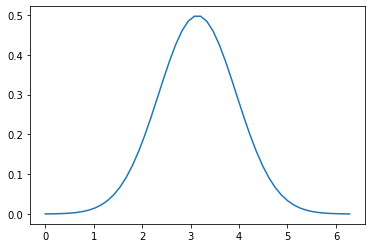

In [245]:
mu, sigma = np.pi, 0.8
gauss = stats.norm(mu, sigma).pdf

xs = np.linspace(0, 2*np.pi, 50)
plt.plot(xs, gauss(xs))

# Noise

In [13]:

def noise_speed_color():
    return A.NoiseCycle(
        hz=L.Named('arousal') | S.Lin(mult=-5, shift=5),
    ) | C.InterpolPalette(L.Named('valence'), (
        (0, P.black_violet),
        #(.5, P.black_white),
        (1, P.coolors_rainbow),
    )) | S.Lin(mult=L.Named('arousal')) | S.Lin(0, 0.5)


a = noise_speed_color()
a(t=0, arousal=0.5, valence=0.5)

AttributeError: module 'smanmi.colors' has no attribute 'InterpolPalette'

In [14]:
# https://github.com/pvigier/perlin-numpy#3d-fractal-noise
import perlin_numpy

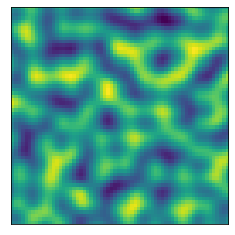

In [15]:
np.random.seed(0)
x = perlin_numpy.generate_perlin_noise_2d(shape=(64, 64), res=(8, 8))
plt.imshow(x, interpolation='nearest')
plt.gca().set_xticks([]); plt.gca().set_yticks([]);

In [16]:
%timeit perlin_numpy.generate_perlin_noise_2d((64, 64), (8, 8))

480 µs ± 15.5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [17]:
# scales with number of pixels, i.e. img_res^2
%timeit perlin_numpy.generate_perlin_noise_2d((256, 256), (8, 8))

6.25 ms ± 132 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [18]:
# does not depend on 'res' parameter
%timeit perlin_numpy.generate_perlin_noise_2d((64, 64), (16, 16))

506 µs ± 25.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


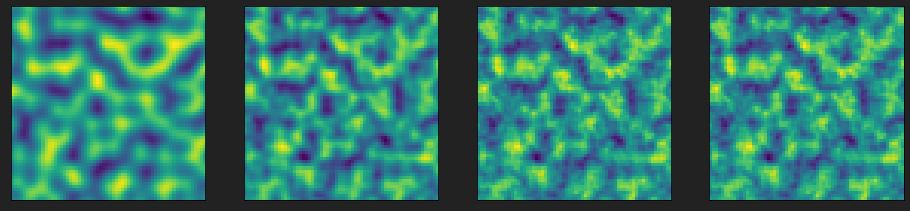

In [19]:
n = 4
_, axs = plt.subplots(1, n, facecolor='#222', figsize=(4 * n, 4))
for i in range(n):
    np.random.seed(0)
    x = perlin_numpy.generate_fractal_noise_2d((64, 64), (8, 8), octaves=i + 1)
    axs[i].imshow(x, interpolation='nearest')
    axs[i].set_xticks([]); axs[i].set_yticks([])

In [46]:
?perlin_numpy.generate_fractal_noise_3d

Signature:
perlin_numpy.generate_fractal_noise_3d(
    shape,
    res,
    octaves=1,
    persistence=0.5,
    lacunarity=2,
    tileable=(False, False, False),
    interpolant=<function interpolant at 0x12a8ef280>,
)
Docstring:
Generate a 3D numpy array of fractal noise.

Args:
    shape: The shape of the generated array (tuple of three ints).
        This must be a multiple of lacunarity**(octaves-1)*res.
    res: The number of periods of noise to generate along each
        axis (tuple of three ints). Note shape must be a multiple of
        (lacunarity**(octaves-1)*res).
    octaves: The number of octaves in the noise. Defaults to 1.
    persistence: The scaling factor between two octaves.
    lacunarity: The frequency factor between two octaves.
    tileable: If the noise should be tileable along each axis
        (tuple of three bools). Defaults to (False, False, False).
    interpolant: The, interpolation function, defaults to
        t*t*t*(t*(t*6 - 15) + 10).

Returns:
    A n

In [20]:
%timeit perlin_numpy.generate_fractal_noise_2d((64, 64), (8, 8), octaves=4)

2.18 ms ± 112 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [51]:

# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import numpy as np

import time
t0 = time.time()

np.random.seed(0)
noise = perlin_numpy.generate_fractal_noise_3d(
    (32 * 10, 256, 256), (1, 4, 4), 4, tileable=(True, False, False)
)

time.time() - t0
# fig = plt.figure()
# images = [
#     [plt.imshow(
#         layer, cmap='gray', interpolation='lanczos', animated=True
#     )]
#     for layer in noise
# ]
# animation_3d = animation.ArtistAnimation(fig, images, interval=50, blit=True)
# plt.show()

26.029945135116577

In [27]:
!../env/bin/pip install -q imageio-ffmpeg

You should consider upgrading via the '/Users/ast/git/nuru/env/bin/python -m pip install --upgrade pip' command.


In [53]:
import imageio
from IPython.display import Video

noise8 = (255 * (noise - noise.min()) / (noise.max() - noise.min())).astype(np.uint8)
noise8_3d = noise8[..., None] * np.ones([1, 1, 1, 3], np.uint8)

imageio.mimwrite('test2.mp4', noise8_3d, fps=60); 
Video('test2.mp4', width=256, height=256, html_attributes='loop autoplay controls') #the width and height option as additional thing new in Ipython 7.6.1

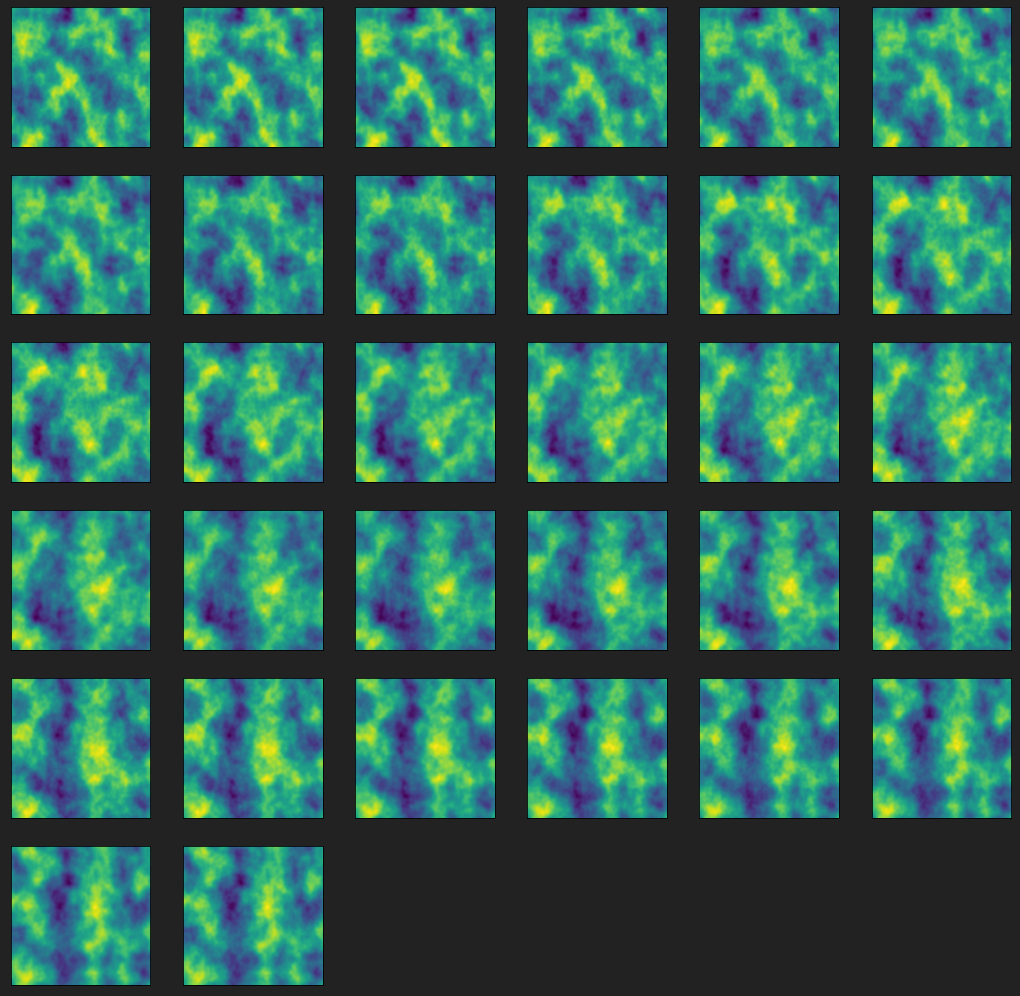

In [24]:
n = int(np.ceil(len(noise) ** .5))
_, axs = plt.subplots(n, n, figsize=(3*n, 3*n), facecolor='#222')
for i, layer in enumerate(noise):
    axs[i // n][i % n].imshow(layer)
    axs[i // n][i % n].set_xticks([]); axs[i // n][i % n].set_yticks([])
for i in range(len(noise), n*n):
    axs[i // n][i % n].axis('off')

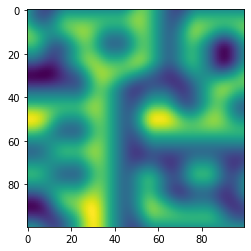

In [9]:
# so/42147776

def perlin(x,y,seed=0):
    # permutation table
    np.random.seed(seed)
    p = np.arange(256,dtype=int)
    np.random.shuffle(p)
    p = np.stack([p,p]).flatten()
    # coordinates of the top-left
    xi = x.astype(int)
    yi = y.astype(int)
    # internal coordinates
    xf = x - xi
    yf = y - yi
    # fade factors
    u = fade(xf)
    v = fade(yf)
    # noise components
    n00 = gradient(p[p[xi]+yi],xf,yf)
    n01 = gradient(p[p[xi]+yi+1],xf,yf-1)
    n11 = gradient(p[p[xi+1]+yi+1],xf-1,yf-1)
    n10 = gradient(p[p[xi+1]+yi],xf-1,yf)
    # combine noises
    x1 = lerp(n00,n10,u)
    x2 = lerp(n01,n11,u) # FIX1: I was using n10 instead of n01
    return lerp(x1,x2,v) # FIX2: I also had to reverse x1 and x2 here

def lerp(a,b,x):
    "linear interpolation"
    return a + x * (b-a)

def fade(t):
    "6t^5 - 15t^4 + 10t^3"
    return 6 * t**5 - 15 * t**4 + 10 * t**3

def gradient(h,x,y):
    "grad converts h to the right gradient vector and return the dot product with (x,y)"
    vectors = np.array([[0,1],[0,-1],[1,0],[-1,0]])
    g = vectors[h%4]
    return g[:,:,0] * x + g[:,:,1] * y

lin = np.linspace(0,5,100,endpoint=False)
x,y = np.meshgrid(lin,lin) # FIX3: I thought I had to invert x and y here but it was a mistake

plt.imshow(perlin(x,y,seed=2),origin='upper')

# Self-Organising Textures

on Drive:

- https://colab.research.google.com/drive/1m_ccHBH3WPIH2coND8MZbaTiBBTI0VKF
- https://drive.google.com/drive/folders/1p5JYFtVrQBcAALRz9MzXCQqDhdo8hQ8x

original article

- https://distill.pub/selforg/2021/textures/


## using xy_mapping

In [372]:
import imageio
from IPython.display import Video

data = np.load('../images/kissen.npy', allow_pickle=True)
anim = A.NCA2D(data, A.xy_mapping, speed=1, wrapx=True)

frames = []
leds = []
for _ in range(100):
    leds.append(anim())
    img = anim.img.transpose([1, 0, 2])
    frames.append((255*img).astype(np.uint8))

imageio.mimwrite('nca.mp4', frames, fps=20); 
Video('nca.mp4', html_attributes='loop autoplay controls') #, width=256, height=256)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (180, 34) to (192, 48) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [369]:
d = DisplayS()
imageio.mimwrite('nca_disp.mp4', [np.asarray(d.draw(led)) for led in leds], fps=20); 
Video('nca_disp.mp4', html_attributes='loop autoplay controls') #, width=256, height=256)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (380, 280) to (384, 288) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## project r-phi -> img

(1920, 2)

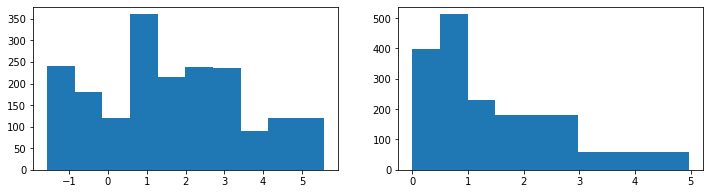

In [21]:
_, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].hist(A.phi_r_mapping[:, 0])  # phi ~2*pi
axs[1].hist(A.phi_r_mapping[:, 1])  # r : circle <1, short arms 1..3, long arms 1..5
A.phi_r_mapping.shape

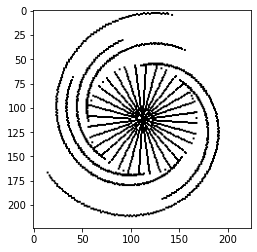

In [45]:
img = np.ones([224, 224, 3], np.float)

def make_spiralled(ratio, dpdr):
    m = A.phi_r_mapping
    center = m[:, 1] <= 1
    arms = ~center
    ret = np.zeros(m.shape, np.float)
    R = m[:, 1].max()
    ret[center, 0] = .5 + .5*ratio*m[center, 1] * np.cos(m[center, 0])
    ret[center, 1] = .5 + .5*ratio*m[center, 1] * np.sin(m[center, 0])
    ret[arms, 0] = .5 + (.5*ratio + .5*(1 - ratio)*(m[arms,1]-1)/(R-1)) * np.cos(m[arms,0] + dpdr*(m[arms,1]-1))
    ret[arms, 1] = .5 + (.5*ratio + .5*(1 - ratio)*(m[arms,1]-1)/(R-1)) * np.sin(m[arms,0] + dpdr*(m[arms,1]-1))
    return ret

def draw(img, xy, sz=1):
    img = np.array(img)
    h, w, *_ = img.shape
    for x, y in xy:
        x, y = int(w*x), int(h*y)
        img[y-sz//2:y-sz//2+sz+1, x-sz//2:x-sz//2+sz+1, :] = 0
    return img

plt.imshow(draw(img, make_spiralled(0.5, np.pi/3)))

(array([399., 512., 229., 180., 180., 180.,  60.,  60.,  60.,  60.]),
 array([0.        , 0.04966667, 0.09933333, 0.149     , 0.19866667,
        0.24833333, 0.298     , 0.34766667, 0.39733333, 0.447     ,
        0.49666667]),
 <BarContainer object of 10 artists>)

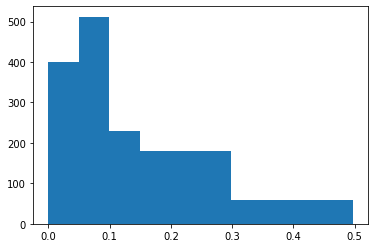

In [238]:
# TMP
plt.hist(
(A.Dist2D(0, 0) | S.From(0, 5) | S.To(0, .5))()
)

In [62]:
m = make_spiralled(0.5, np.pi/3)
.shape

(1920, 2)

In [221]:
import tensorflow as tf

from self_organising_systems.texture_ca import ca

class NCA2D(L.Signal):
    """Runs a neural cellular automaton in 2D & retrieves mapped pixels."""
    
    def init(self, name, speed=1, height=192, width=192, channel_n=12):
        self.data = np.load(f'../images/{name}.npy', allow_pickle=True)
        self.f = ca.CAModel(self.data).embody()
        self.x = tf.zeros([1, height, width, channel_n])
        self.counter = 0
        m = make_spiralled(0.5, np.pi/3)
        self.m = np.c_[m[:, 0] * height, m[:, 1] * width].astype('int')
        
    def call(self):
        self.counter += 1
        while self.counter >= 1/self.speed:
            self.x = self.f(self.x)
            self.counter -= 1/self.speed
        img = ca.to_rgb(self.x)[0].numpy()
#         return img
        return img[self.m[:, 0], self.m[:, 1], :]
        
anim = NCA2D('kissen', speed=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


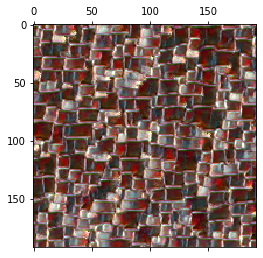

In [220]:
plt.matshow(anim())

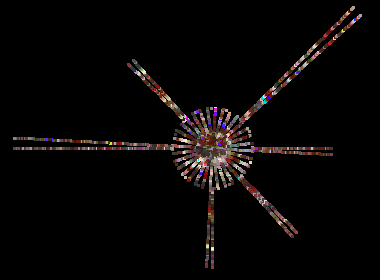

In [232]:
DisplayS().draw(anim())

In [118]:
a().shape

<class 'numpy.ndarray'> (192, 192, 3) (1920, 2)


(1920, 3)

In [116]:
a = np.array([[0, 0], [1, 1], [2, 2]])
x = np.zeros([5, 5, 4])
np.take(x, a)
x[a[:, 0], a[:, 1], :]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

# animated animations

using matplot lib animations...

you're probably better off using the new code above with the r-phi/GIF animations

In [209]:
import random
from matplotlib import animation, rc
from IPython.display import HTML

rc('animation', html='html5')

class MatplotlibAnimation:
    def __init__(self, xlim=[-1, 1], ylim=[-1, 1], frames=100, interval=20, figsize=(4, 4)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_xlim(xlim)
        self.ax.set_ylim(ylim)
        self.line, = self.ax.plot([], [])
        self.frames, self.interval = frames, interval

    def init(self):
        self.line.set_data([], [])
        return self.line,

    def step(self, i):
        return self.line,

    def animate(self, frames=None, interval=None):
        if frames is None: frames = self.frames
        if interval is None: interval = self.interval
        return animation.FuncAnimation(
            self.fig, self.step, init_func=self.init, frames=frames, interval=interval, blit=True)

    def play(self, animation=None, **animate_kw):
        if animation is None:
            animation = self.animate(**animate_kw)
        plt.close(animation._fig)
        return HTML(animation.to_html5_video())

## stereo drone

In [210]:
class ArmDecay(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return v * (1 - self.xs)**4

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 20),
    np.ones(3*20),
    np.linspace(1, 0, 20),
])

In [211]:
ArmDecay(ramp).play()

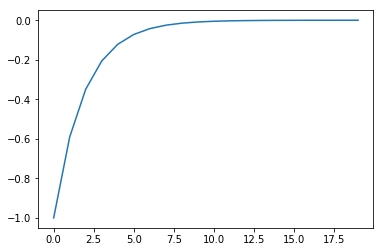

In [20]:
plt.plot(-np.exp(-np.linspace(0, 10, 20)))

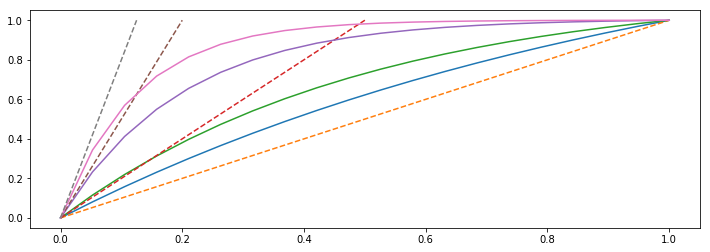

In [21]:
def decay(dx0, xs):
    """dx0 : initial steepness, xs : values 0..1"""
    ret = 1 - np.exp(-xs * dx0)
    return ret / ret[-1]

xs = np.linspace(0, 1, 20)
plt.figure(figsize=(12, 4))
for dx0 in (1, 2, 5, 8):
    plt.plot(xs, decay(dx0, xs))
    plt.plot([0, 1/dx0], [0, 1], '--')
# plt.plot(decay(2, xs))
# plt.plot(decay(4, xs))
# plt.plot(decay(8, xs))

In [22]:
class ArmImpulse(MatplotlibAnimation):
    def __init__(self, values, n=100):
        super().__init__(xlim=(0, 1), ylim=(0, 1.1), frames=len(values), figsize=(12, 4))
        self.values = values
        self.n = n
        self.xs = np.linspace(0, 1, n)
        self.frames = len(values)
        
    def f(self, v):
        return 1 * (np.abs(v - self.xs) < 0.02)

    def step(self, i):
        self.line.set_data(self.xs, self.f(self.values[i]))
        return self.line,

ramp = np.concatenate([
    np.linspace(0, 1, 40),
    np.ones(40),
])
ArmImpulse(ramp).play()

## chase

In [23]:

class RandomWalk(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0

    def step(self, i):
        self.x += random.random() * 0.2 - 0.1
        self.y += random.random() * 0.2 - 0.1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,


class RandomWalkV(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.x = self.y = 0
        self.vx = self.vy = 0
    def step(self, i):
        self.vx += random.random() * 0.02 - 0.01
        self.vy += random.random() * 0.02 - 0.01
        self.x += self.vx
        self.y += self.vy
        if self.x < -1 or self.x > 1:
            self.x -= 2 * self.vx
            self.vx *= -1
        if self.y < -1 or self.y > 1:
            self.y -= 2 * self.vy
            self.vy *= -1
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,
    

class RandomWalkD(MatplotlibAnimation):
    def __init__(self):
        super().__init__()
        self.xs = []
        self.ys = []
        self.phi = 0
        self.x = self.y = 0
    def step(self, i):
        if self.x < -0.9 or self.x > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(y, -x)
        if self.y < -0.9 or self.y > 0.9:
            x, y = np.sin(self.phi), np.cos(self.phi)
            self.phi = np.arctan2(-y, x)
        self.phi += (random.random() - 0.5) * np.pi / 5
        self.x += 0.1 * np.sin(self.phi)
        self.y += 0.1 * np.cos(self.phi)
        self.xs.append(self.x)
        self.ys.append(self.y)
        self.line.set_data(self.xs, self.ys)
        return self.line,

In [24]:
RandomWalkD().play(frames=100)

In [25]:
RandomWalkV().play(frames=300)

In [26]:
RandomWalk().play(frames=100)